Load Datasets:

In [1]:
import pandas as pd

customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
products = pd.read_csv("data/products.csv")
sales = pd.read_csv("data/sales.csv")

Quick checking of the data:

In [15]:
print("CUSTOMERS DATASET: \n", customers.head())
print("\n")
print("ORDERS DATASET: \n",orders.head())
print("\n")
print("PRODUCTS DATASET: \n",products.head())
print("\n")
print("SALES DATASET: \n",sales.head())

CUSTOMERS DATASET: 
   customer_id    customer_name    segment
0    CG-12520      Claire Gute   Consumer
1    DV-13045  Darrin Van Huff  Corporate
2    SO-20335   Sean O'Donnell   Consumer
3    BH-11710  Brosina Hoffman   Consumer
4    AA-10480     Andrew Allen   Consumer


ORDERS DATASET: 
          order_id order_date  ship_date       ship_mode customer_id
0  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520
1  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045
2  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335
3  CA-2015-115812 2015-06-09 2015-06-14  Standard Class    BH-11710
4  CA-2018-114412 2018-04-15 2018-04-20  Standard Class    AA-10480


PRODUCTS DATASET: 
         product_id                                       product_name  \
0  FUR-BO-10001798                  Bush Somerset Collection Bookcase   
1  FUR-CH-10000454  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
2  OFF-LA-10000240  Self-Adhesive Address Labels for Typew

Fixing datetime, to ensure correct time-based analysis:

In [14]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["ship_date"] = pd.to_datetime(orders["ship_date"])

In [16]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 4922 entries, 0 to 4921
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     4922 non-null   str           
 1   order_date   4922 non-null   datetime64[us]
 2   ship_date    4922 non-null   datetime64[us]
 3   ship_mode    4922 non-null   str           
 4   customer_id  4922 non-null   str           
dtypes: datetime64[us](2), str(3)
memory usage: 192.4 KB


We now see that datetime is no longer "str", but now "datetime64[us]"

SQL Analysis:

In [5]:
import sqlite3

conn = sqlite3.connect(':memory:')

customers.to_sql("customers", conn, index=False)
orders.to_sql("orders", conn, index=False)
products.to_sql("products", conn, index=False)
sales.to_sql("sales", conn, index=False)

9800

Query 1 - Total Sales by Category

In [20]:
query_total_sales_by_category = """
SELECT category, SUM(sales) AS total_sales
FROM products
JOIN sales ON products.product_id = sales.product_id
GROUP BY category
ORDER BY total_sales DESC
"""

total_sales_by_category = pd.read_sql(query_total_sales_by_category, conn)
total_sales_by_category

,category,total_sales
0,Technology,884735.1420
1,Furniture,750688.2347
2,Office Supplies,722640.9040


Query 2 - Total Sales by Customer Segment

In [24]:
query_total_sales_by_customer_segment = """
SELECT segment, SUM(sales) AS total_sales
FROM sales
JOIN orders ON sales.order_id = orders.order_id
JOIN customers ON orders.customer_id = customers.customer_id
GROUP BY segment
ORDER BY total_sales DESC
"""

total_sales_by_customer_segment = pd.read_sql(query_total_sales_by_customer_segment, conn)
total_sales_by_customer_segment

,segment,total_sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


Query 3 - Monthly Sales Trend

In [27]:
query_monthly_sales_trend = """
WITH monthly_sales AS (
    SELECT strftime('%Y-%m', order_date) AS order_month, SUM(sales) AS total_sales
    FROM sales
    JOIN orders ON sales.order_id = orders.order_id
    GROUP BY order_month
),
monthly_sales_with_previous AS (
    SELECT
        order_month,
        total_sales,
        LAG(total_sales) OVER (ORDER BY order_month) AS previous_month_sales
    FROM monthly_sales
)
SELECT
    order_month,
    total_sales,
    previous_month_sales,
    total_sales - previous_month_sales AS monthly_growth
FROM monthly_sales_with_previous
ORDER BY order_month ASC;
"""

monthly_sales_trend = pd.read_sql(query_monthly_sales_trend, conn)
monthly_sales_trend

,order_month,total_sales,previous_month_sales,monthly_growth
0,2015-01,14205.7070,NaN,NaN
1,2015-02,4519.8920,14205.7070,-9685.8150
2,2015-03,55205.7970,4519.8920,50685.9050
3,2015-04,27906.8550,55205.7970,-27298.9420
4,2015-05,23644.3030,27906.8550,-4262.5520
5,2015-06,34322.9356,23644.3030,10678.6326
6,2015-07,33781.5430,34322.9356,-541.3926
7,2015-08,27117.5365,33781.5430,-6664.0065
8,2015-09,81623.5268,27117.5365,54505.9903
9,2015-10,31453.3930,81623.5268,-50170.1338


Query 4 - Top 10 Customers by Total Sales

In [39]:
query_top_customers_by_total_sales = """
SELECT customers.customer_id, customer_name, SUM(sales) AS total_sales
FROM sales
JOIN orders ON sales.order_id = orders.order_id
JOIN customers ON orders.customer_id = customers.customer_id
GROUP BY customers.customer_id, customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""
top_customers_by_total_sales = pd.read_sql(query_top_customers_by_total_sales, conn)
top_customers_by_total_sales

,customer_id,customer_name,total_sales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571
5,KL-16645,Ken Lonsdale,14175.229
6,SC-20095,Sanjit Chand,14142.334
7,HL-15040,Hunter Lopez,12873.298
8,SE-20110,Sanjit Engle,12209.438
9,CC-12370,Christopher Conant,12129.072


Query 5 - Average Order Value by Customer Segment

(How valuable is each segment on average?)

In [66]:
query_average_order_value_by_customer_segment = """
WITH order_totals AS (
    SELECT
        sales.order_id,
        customers.segment,
        SUM(sales.sales) AS order_total
    FROM sales
    JOIN orders ON sales.order_id = orders.order_id
    JOIN customers ON orders.customer_id = customers.customer_id
    GROUP BY sales.order_id, customers.segment
)
SELECT
    segment,
    AVG(order_total) AS average_order_value
FROM order_totals
GROUP BY segment
ORDER BY average_order_value DESC;
"""

average_order_value_by_customer_segment = pd.read_sql(query_average_order_value_by_customer_segment, conn)
average_order_value_by_customer_segment

,segment,average_order_value
0,Home Office,475.371563
1,Corporate,461.766650
2,Consumer,452.526816


Visualizations

Total Sales by Category:

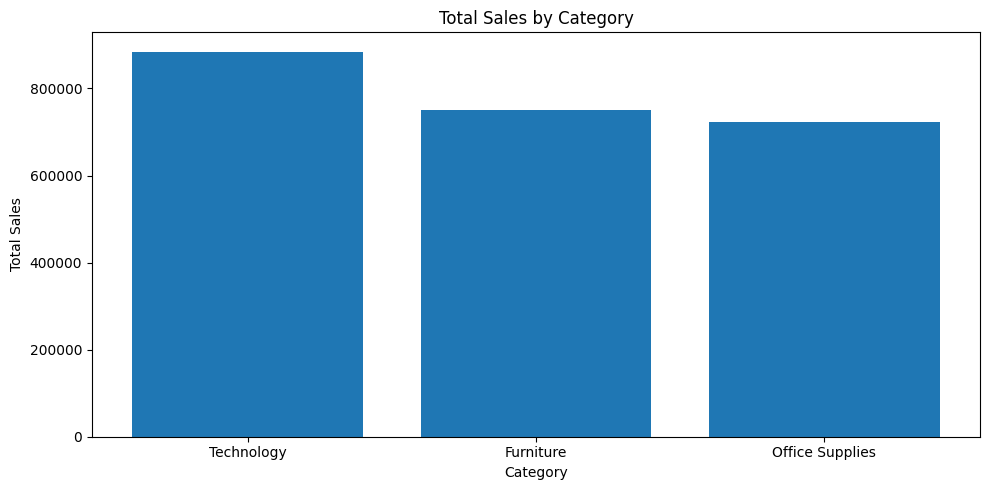

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(total_sales_by_category["category"], total_sales_by_category["total_sales"])

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Total Sales by Segment:

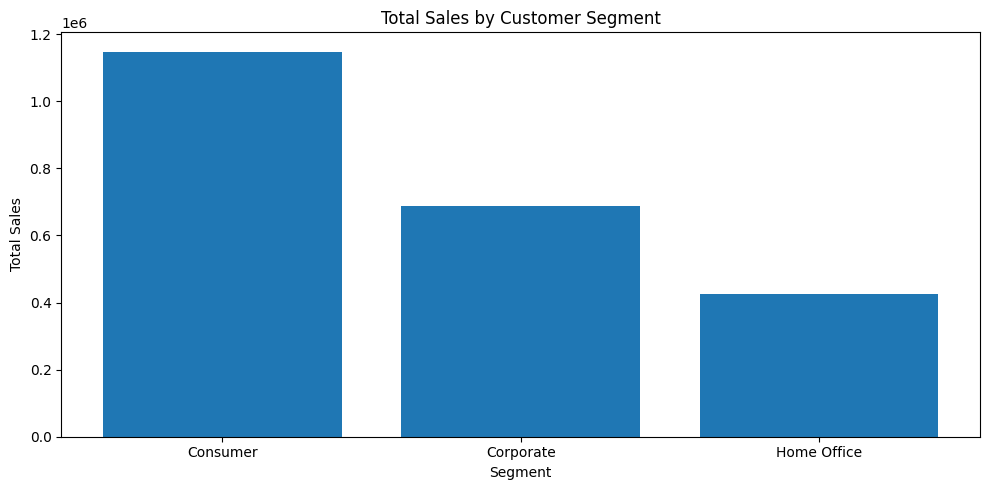

In [68]:
plt.figure(figsize=(10, 5))

plt.bar(total_sales_by_customer_segment["segment"], total_sales_by_customer_segment["total_sales"])

plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Monthly Sales Trend:

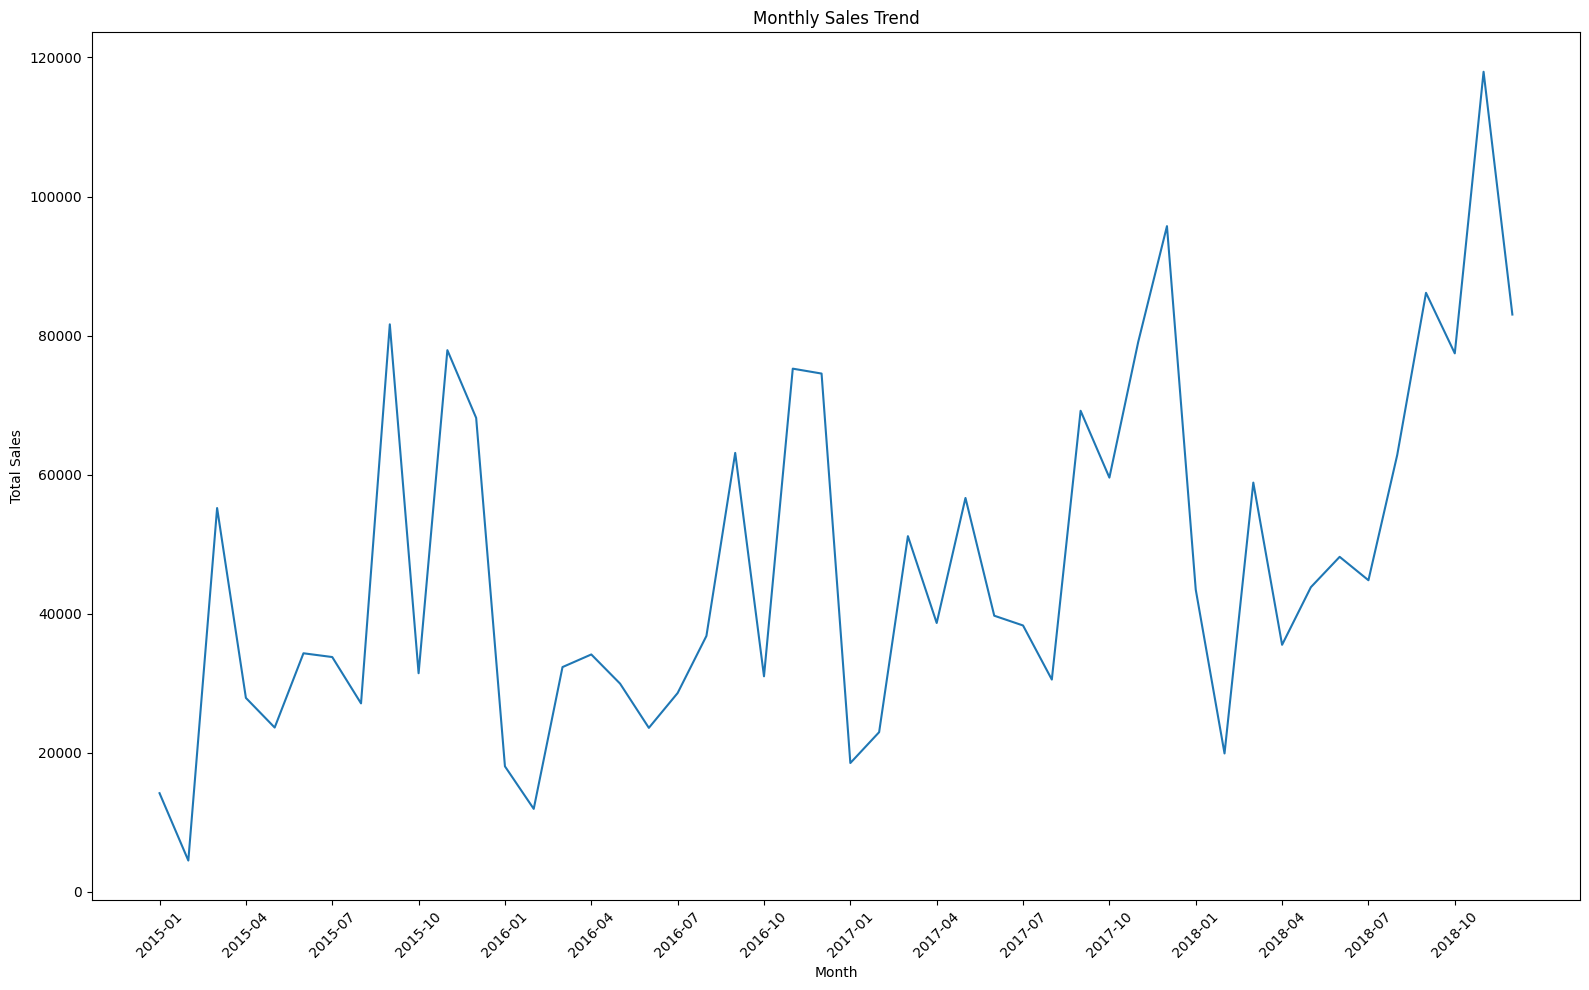

In [75]:
plt.figure(figsize=(16, 10))
plt.plot(monthly_sales_trend["order_month"], monthly_sales_trend["total_sales"])

plt.xticks(monthly_sales_trend["order_month"][::3], rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Order Value by Segment:

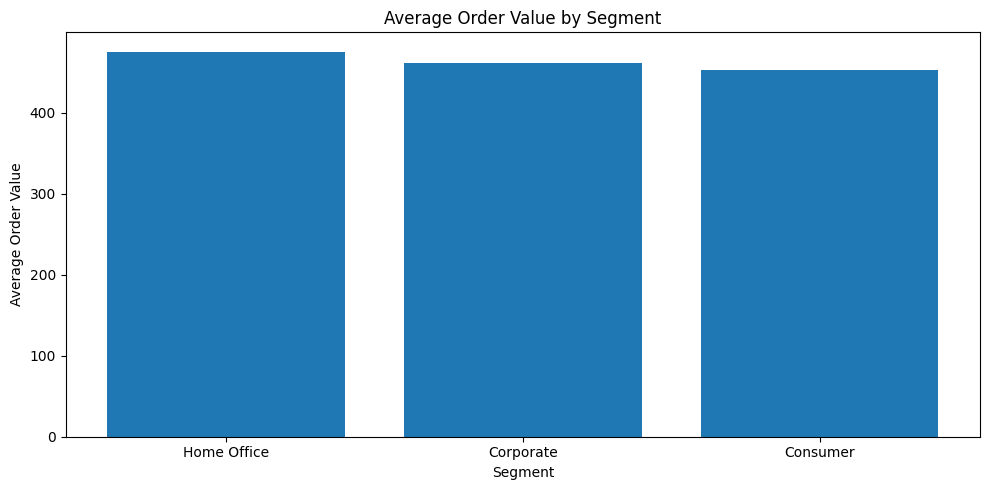

In [71]:
plt.figure(figsize=(10, 5))

plt.bar(average_order_value_by_customer_segment["segment"],
        average_order_value_by_customer_segment["average_order_value"])

plt.title("Average Order Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

Insights:
- Technology generates the highest total sales, although the difference compared to Furniture and Office Supplies is moderate.

- The Consumer segment contributes the largest share of total sales, followed by Corporate and Home Office, indicating that individual consumers are the primary revenue drivers.

- Monthly sales show noticeable volatility but follow an overall upward trend over time.

- Average order value is similar across all customer segments, suggesting that differences in total sales are driven more by order volume than by order size.